In [2]:
import numpy as numpy
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
df  = pd.read_csv(r'C:\Users\Yashasvi\Documents\Machine-Learning-Project\student_marks_prediction\student_info.csv')
df.head()

,study_hours,student_marks
0,6.83,78.50
1,6.56,76.74
2,NaN,78.68
3,5.67,71.82
4,8.67,84.19


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   study_hours    195 non-null    float64
 1   student_marks  200 non-null    float64
dtypes: float64(2)
memory usage: 3.2 KB


In [11]:
df.describe()

,study_hours,student_marks
count,195.000000,200.00000
mean,6.995949,77.93375
std,1.253060,4.92570
min,5.010000,68.57000
25%,5.775000,73.38500
50%,7.120000,77.71000
75%,8.085000,82.32000
max,8.990000,86.99000


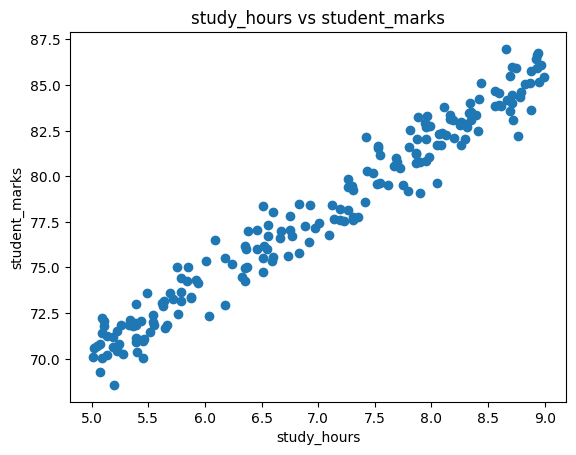

In [12]:
plt.scatter(x=df.study_hours,y=df.student_marks)
plt.xlabel("study_hours")
plt.ylabel("student_marks")
plt.title("study_hours vs student_marks")
plt.show()

In [13]:
df.isnull().sum()

study_hours      5
student_marks    0
dtype: int64

In [14]:
df2=df.fillna(df.mean())

In [15]:
df2

,study_hours,student_marks
0,6.830000,78.50
1,6.560000,76.74
2,6.995949,78.68
3,5.670000,71.82
4,8.670000,84.19
...,...,...
195,7.530000,81.67
196,8.560000,84.68
197,8.940000,86.75
198,6.600000,78.05


In [16]:
df2.isnull().sum()

study_hours      0
student_marks    0
dtype: int64

In [17]:
x = df2.drop("student_marks",axis="columns")
y = df2.drop("study_hours",axis="columns")
print("shape of x = ",x.shape)
print("shape of y = ",y.shape)

shape of x =  (200, 1)
shape of y =  (200, 1)


In [18]:
x

,study_hours
0,6.830000
1,6.560000
2,6.995949
3,5.670000
4,8.670000
...,...
195,7.530000
196,8.560000
197,8.940000
198,6.600000


In [19]:
y

,student_marks
0,78.50
1,76.74
2,78.68
3,71.82
4,84.19
...,...
195,81.67
196,84.68
197,86.75
198,78.05


In [20]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x , y ,test_size=0.2,random_state=0)

print("shape of x_train = ",x_train.shape)
print("shape of x_test = ",x_test.shape)
print("shape of y_train = ",y_train.shape)
print("shape of y_test = ",y_test.shape)

shape of x_train =  (160, 1)
shape of x_test =  (40, 1)
shape of y_train =  (160, 1)
shape of y_test =  (40, 1)


In [21]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
lr.get_params()

{'copy_X': True,
 'fit_intercept': True,
 'n_jobs': None,
 'positive': False,
 'tol': 1e-06}

In [24]:
lr.coef_ 

array([[3.93037294]])

In [25]:
lr.intercept_

array([50.45063632])

In [26]:
m =3.9
c = 50.45
y= 3.9*10+50.45  # x= hours
y                # y= marks

89.45

In [27]:
lr.predict([[10]]).round(2)

c:\Users\Yashasvi\anaconda3\envs\newenv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[89.75]])

In [28]:
y_pred= lr.predict(x_test)
y_pred

array([[83.50507271],
       [70.84927186],
       [72.93236952],
       [85.35234799],
       [73.20749562],
       [84.48766595],
       [80.12495199],
       [81.85431608],
       [80.91102657],
       [82.20804964],
       [78.98514384],
       [84.84139951],
       [77.84533568],
       [77.68812077],
       [83.22994661],
       [85.78468901],
       [84.9593107 ],
       [72.61793968],
       [78.71001773],
       [79.18166248],
       [84.2911473 ],
       [85.6274741 ],
       [74.74034107],
       [81.3433676 ],
       [72.02838374],
       [80.40007809],
       [78.98514384],
       [82.09013845],
       [77.94732382],
       [82.24735337],
       [75.44780819],
       [84.60557713],
       [71.63534645],
       [75.48711192],
       [70.29901965],
       [78.98514384],
       [75.32989701],
       [84.52696967],
       [74.07217767],
       [71.4388278 ]])

In [29]:
import numpy as np
pd.DataFrame(np.c_[x_test,y_test,y_pred],columns=["study_hours","student_marks_ori","students_marks_pred"])


,study_hours,student_marks_ori,students_marks_pred
0,8.410000,82.50,83.505073
1,5.190000,71.18,70.849272
2,5.720000,73.25,72.932370
3,8.880000,83.64,85.352348
4,5.790000,73.64,73.207496
5,8.660000,86.99,84.487666
6,7.550000,81.18,80.124952
7,7.990000,82.75,81.854316
8,7.750000,79.50,80.911027
9,8.080000,81.70,82.208050


In [30]:
lr.score(x_train,y_train)  # variance

0.9584528455152638

In [31]:
lr.score(x_test,y_test) # bais

0.9521841793508594

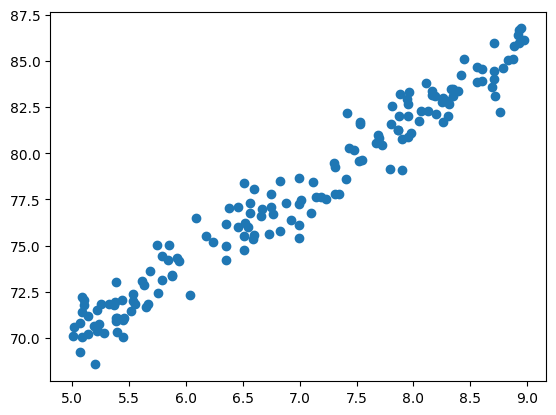

In [32]:
plt.scatter(x_train,y_train)

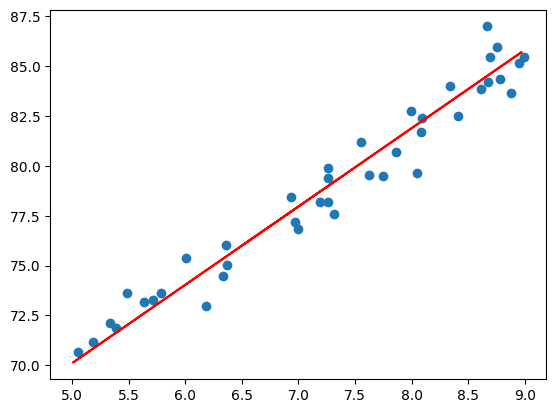

In [33]:
plt.scatter(x_test,y_test)
plt.plot(x_train,lr.predict(x_train),color='r')

In [34]:
import pickle
filename = 'desktop.pkl'
with open(filename,'wb') as file:
    pickle.dump(lr,file)
print('Model has been pickled and saved as desktop.pkl')

Model has been pickled and saved as desktop.pkl
